Data preposessing

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import io

Dataset load

In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("nitirajkulkarni/dhaka-bd-1185241")

print("Path to dataset files:", path)

# Load the air quality historical data into a pandas DataFrame
file_name = "air_quality_historical.csv"
full_file_path = os.path.join(path, file_name)

try:
    df = pd.read_csv(full_file_path)
    print(f"\nDataFrame 'df' loaded successfully from {file_name}.")
    print("First 10 records:")
    display(df.head(10))
except Exception as e:
    print(f"An error occurred while loading the DataFrame: {e}")

Using Colab cache for faster access to the 'dhaka-bd-1185241' dataset.
Path to dataset files: /kaggle/input/dhaka-bd-1185241

DataFrame 'df' loaded successfully from air_quality_historical.csv.
First 10 records:


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,17.227778,11.655556,242.222222,19.538889,3.600000,28.944444,0.165000,0.0,2.761111,NaN,NaN
4,2022-08-05,19.320833,13.012500,267.916667,20.395833,4.679167,32.500000,0.158333,0.0,2.320833,51.555556,26.611111
5,2022-08-06,19.716667,13.525000,279.416667,26.825000,4.462500,26.916667,0.163333,0.0,1.150000,52.583333,26.333333
6,2022-08-07,16.941667,11.545833,258.666667,21.604167,4.325000,44.541667,0.140833,0.0,2.339583,51.291667,28.208333
7,2022-08-08,13.512500,9.037500,210.333333,17.587500,3.191667,44.458333,0.125833,0.0,2.377083,43.750000,23.125000
8,2022-08-09,10.787500,7.216667,177.708333,14.270833,2.712500,46.916667,0.118333,0.0,1.564583,32.750000,19.083333
9,2022-08-10,9.383333,6.325000,175.125000,13.583333,2.750000,48.500000,0.105833,0.0,1.812500,27.958333,19.500000


In [ ]:
print(f"Total number of data points (rows): {len(df)}")

Total number of data points (rows): 1298


Missing Value

In [ ]:
print("--- MISSING VALUES CHECK ---")
null_counts = df.isna().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Zero missing values detected across all columns.")

# Detect pollutant column name (handles minor naming variations)
pm25_col = [c for c in df.columns if 'pm2_5' in c.lower() or 'pm25' in c.lower()][0]
print(f"\nTarget Particulate Column Identified: '{pm25_col}'")

--- MISSING VALUES CHECK ---
pm10                     3
pm2_5                    3
carbon_monoxide          3
nitrogen_dioxide         3
sulphur_dioxide          3
ozone                    3
aerosol_optical_depth    3
dust                     3
uv_index                 3
us_aqi                   4
european_aqi             4
dtype: int64

Target Particulate Column Identified: 'pm2_5'


### Handling Missing Values



In [ ]:
# Identify columns with missing values
columns_with_missing_values = df.columns[df.isnull().any()].tolist()

print(f"Columns with missing values before imputation: {columns_with_missing_values}")

# Apply forward fill and then backward fill to the DataFrame
# Using the recommended syntax for pandas FutureWarning
df_imputed = df.ffill().bfill()

# Verify that missing values have been handled
print("\n--- MISSING VALUES CHECK AFTER IMPUTATION ---")
null_counts_after = df_imputed.isna().sum()
print(null_counts_after[null_counts_after > 0] if null_counts_after.sum() > 0 else "Zero missing values detected across all columns.")

# Display the first few rows of the imputed DataFrame to show changes
print("\nFirst 10 rows of DataFrame after imputation:")
display(df_imputed.head(10))

df = df_imputed.copy()

Columns with missing values before imputation: ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi']

--- MISSING VALUES CHECK AFTER IMPUTATION ---
Zero missing values detected across all columns.

First 10 rows of DataFrame after imputation:


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,17.227778,11.655556,242.222222,19.538889,3.600000,28.944444,0.165000,0.0,2.761111,51.555556,26.611111
1,2022-08-02,17.227778,11.655556,242.222222,19.538889,3.600000,28.944444,0.165000,0.0,2.761111,51.555556,26.611111
2,2022-08-03,17.227778,11.655556,242.222222,19.538889,3.600000,28.944444,0.165000,0.0,2.761111,51.555556,26.611111
3,2022-08-04,17.227778,11.655556,242.222222,19.538889,3.600000,28.944444,0.165000,0.0,2.761111,51.555556,26.611111
4,2022-08-05,19.320833,13.012500,267.916667,20.395833,4.679167,32.500000,0.158333,0.0,2.320833,51.555556,26.611111
5,2022-08-06,19.716667,13.525000,279.416667,26.825000,4.462500,26.916667,0.163333,0.0,1.150000,52.583333,26.333333
6,2022-08-07,16.941667,11.545833,258.666667,21.604167,4.325000,44.541667,0.140833,0.0,2.339583,51.291667,28.208333
7,2022-08-08,13.512500,9.037500,210.333333,17.587500,3.191667,44.458333,0.125833,0.0,2.377083,43.750000,23.125000
8,2022-08-09,10.787500,7.216667,177.708333,14.270833,2.712500,46.916667,0.118333,0.0,1.564583,32.750000,19.083333
9,2022-08-10,9.383333,6.325000,175.125000,13.583333,2.750000,48.500000,0.105833,0.0,1.812500,27.958333,19.500000


Feature Engineering & Time-Lag Creation

In [ ]:
date_col = 'date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)   # safety: guarantee chronological order

df['day_of_week'] = df[date_col].dt.dayofweek
df['month'] = df[date_col].dt.month   # used only for regime labeling, not kept as a model feature

regime_conditions = [
    df['month'].isin([11, 12, 1, 2, 3]),   # Winter (Dry)
    df['month'].isin([6, 7, 8, 9]),        # Monsoon (Wet)
]
regime_choices = ['Winter_Dry', 'Monsoon_Wet']
df['regime'] = np.select(regime_conditions, regime_choices, default='Transition')

df['pm25_lag1'] = df[pm25_col].shift(1)
df['pm25_lag7'] = df[pm25_col].shift(7)
df['pm25_roll3'] = df[pm25_col].rolling(window=3).mean().shift(1)

df_clean = df.dropna().reset_index(drop=True)
print(f"Shape after lag creation: {df_clean.shape}")
print(f"Date range: {df_clean[date_col].min().date()} to {df_clean[date_col].max().date()}")

Shape after lag creation: (1291, 18)
Date range: 2022-08-08 to 2026-02-18


Regime Decoupling & Dataset Shaping Check

In [ ]:
cutoff_date = df_clean[date_col].max() - pd.Timedelta(days=365)
df_train_all = df_clean[df_clean[date_col] < cutoff_date].reset_index(drop=True)
df_test_all = df_clean[df_clean[date_col] >= cutoff_date].reset_index(drop=True)

print(f"\nGlobal cutoff date: {cutoff_date.date()}")
print(f"Train rows: {len(df_train_all)} | Test rows: {len(df_test_all)}")
print("\nRegime counts in TRAIN:")
print(df_train_all['regime'].value_counts())
print("\nRegime counts in TEST (sanity check - all 3 should be non-trivial):")
print(df_test_all['regime'].value_counts())

features = [
    'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide',
    'ozone', 'aerosol_optical_depth', 'dust', 'uv_index',
    'day_of_week', 'pm25_lag1', 'pm25_lag7', 'pm25_roll3'
]
target = pm25_col

X_train_g, y_train_g = df_train_all[features], df_train_all[target]
X_test_g, y_test_g = df_test_all[features], df_test_all[target]

def regime_split(regime_name):
    tr = df_train_all[df_train_all['regime'] == regime_name]
    te = df_test_all[df_test_all['regime'] == regime_name]
    return tr[features], tr[target], te[features], te[target]

X_train_w, y_train_w, X_test_w, y_test_w = regime_split('Winter_Dry')
X_train_m, y_train_m, X_test_m, y_test_m = regime_split('Monsoon_Wet')
X_train_t, y_train_t, X_test_t, y_test_t = regime_split('Transition')



Global cutoff date: 2025-02-18
Train rows: 925 | Test rows: 366

Regime counts in TRAIN:
regime
Winter_Dry     412
Monsoon_Wet    298
Transition     215
Name: count, dtype: int64

Regime counts in TEST (sanity check - all 3 should be non-trivial):
regime
Winter_Dry     152
Monsoon_Wet    122
Transition      92
Name: count, dtype: int64


Time-Series Train/Test Split

In [ ]:
from xgboost import XGBRegressor

def fit_regularized(X_tr, y_tr, val_frac=0.15, seed=42):
    n_val = max(int(len(X_tr) * val_frac), 10)
    X_fit, X_val = X_tr.iloc[:-n_val], X_tr.iloc[-n_val:]
    y_fit, y_val = y_tr.iloc[:-n_val], y_tr.iloc[-n_val:]
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=1.5,
        random_state=seed,
        early_stopping_rounds=30,
        eval_metric='rmse',
    )
    # NOTE: if your xgboost version raises a TypeError on early_stopping_rounds/eval_metric
    # in the constructor, move both into the .fit() call below instead.
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
    print(f"  best_iteration: {model.best_iteration} (out of 500 max)")
    return model

print("Baseline:")
baseline_model = fit_regularized(X_train_g, y_train_g)
print("Winter:")
winter_model = fit_regularized(X_train_w, y_train_w)
print("Monsoon:")
monsoon_model = fit_regularized(X_train_m, y_train_m)
print("Transition:")
transition_model = fit_regularized(X_train_t, y_train_t)

print("\nAll 4 models trained on the SAME time-consistent split, with matched regularization.")


Baseline:
  best_iteration: 267 (out of 500 max)
Winter:
  best_iteration: 236 (out of 500 max)
Monsoon:
  best_iteration: 213 (out of 500 max)
Transition:
  best_iteration: 269 (out of 500 max)

All 4 models trained on the SAME time-consistent split, with matched regularization.


Train the Baseline (Global) Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("\n--- OVERFIT CHECK (train RMSE vs test RMSE per model) ---")
for name, model, Xtr, ytr, Xte, yte in [
    ("Baseline (Global)", baseline_model, X_train_g, y_train_g, X_test_g, y_test_g),
    ("Winter", winter_model, X_train_w, y_train_w, X_test_w, y_test_w),
    ("Monsoon", monsoon_model, X_train_m, y_train_m, X_test_m, y_test_m),
    ("Transition", transition_model, X_train_t, y_train_t, X_test_t, y_test_t),
]:
    tr_rmse = rmse(ytr, model.predict(Xtr))
    te_rmse = rmse(yte, model.predict(Xte))
    gap = te_rmse - tr_rmse
    flag = "  <-- large gap, likely overfitting" if gap > 0.5 * tr_rmse else ""
    print(f"{name:20s} train RMSE: {tr_rmse:6.2f} | test RMSE: {te_rmse:6.2f} | gap: {gap:6.2f}{flag}")

"""Evaluation - per-regime (kept for continuity with your original story)"""

print("\n--- PER-REGIME: BASELINE VS SPECIALIST (same held-out test rows now) ---")
for name, Xte, yte, spec_model in [
    ("WINTER", X_test_w, y_test_w, winter_model),
    ("MONSOON", X_test_m, y_test_m, monsoon_model),
    ("TRANSITION", X_test_t, y_test_t, transition_model),
]:
    yp_base = baseline_model.predict(Xte)
    yp_spec = spec_model.predict(Xte)
    rb, r2b = rmse(yte, yp_base), r2_score(yte, yp_base)
    rs, r2s = rmse(yte, yp_spec), r2_score(yte, yp_spec)
    print(f"\n[{name}] Global RMSE: {rb:.2f} (R2 {r2b:.2f}) | Specialist RMSE: {rs:.2f} (R2 {r2s:.2f}) "
          f"| Reduction: {((rb - rs) / rb) * 100:.1f}%")


--- OVERFIT CHECK (train RMSE vs test RMSE per model) ---
Baseline (Global)    train RMSE:   8.18 | test RMSE:  10.89 | gap:   2.72
Winter               train RMSE:   8.71 | test RMSE:  12.83 | gap:   4.12
Monsoon              train RMSE:   1.88 | test RMSE:   5.39 | gap:   3.50  <-- large gap, likely overfitting
Transition           train RMSE:   3.24 | test RMSE:   9.12 | gap:   5.88  <-- large gap, likely overfitting

--- PER-REGIME: BASELINE VS SPECIALIST (same held-out test rows now) ---

[WINTER] Global RMSE: 14.78 (R2 0.65) | Specialist RMSE: 12.83 (R2 0.73) | Reduction: 13.2%

[MONSOON] Global RMSE: 4.75 (R2 0.84) | Specialist RMSE: 5.39 (R2 0.79) | Reduction: -13.3%

[TRANSITION] Global RMSE: 9.01 (R2 0.78) | Specialist RMSE: 9.12 (R2 0.77) | Reduction: -1.2%


Train the Dual-Regime Models

In [ ]:
y_pred_global_full = baseline_model.predict(X_test_g)

y_pred_w = winter_model.predict(X_test_w)
y_pred_m = monsoon_model.predict(X_test_m)
y_pred_t = transition_model.predict(X_test_t)
y_true_multi = pd.concat([y_test_w, y_test_m, y_test_t])
y_pred_multi = np.concatenate([y_pred_w, y_pred_m, y_pred_t])

# baseline predicted on the matching rows in the same regime grouping, for a fair paired comparison
y_pred_global_matched = np.concatenate([
    baseline_model.predict(X_test_w), baseline_model.predict(X_test_m), baseline_model.predict(X_test_t)
])

rmse_g, r2_g = rmse(y_true_multi, y_pred_global_matched), r2_score(y_true_multi, y_pred_global_matched)
rmse_multi, r2_multi = rmse(y_true_multi, y_pred_multi), r2_score(y_true_multi, y_pred_multi)

print("\n--- FULL-YEAR COMPARISON (same test rows, leak-free) ---")
print(f"Global Baseline RMSE : {rmse_g:.2f} (R2: {r2_g:.2f})")
print(f"Multi-Regime RMSE    : {rmse_multi:.2f} (R2: {r2_multi:.2f})")
print(f"-> Overall Error Reduction: {((rmse_g - rmse_multi) / rmse_g) * 100:.1f}%")



--- FULL-YEAR COMPARISON (same test rows, leak-free) ---
Global Baseline RMSE : 10.89 (R2: 0.88)
Multi-Regime RMSE    : 9.95 (R2: 0.90)
-> Overall Error Reduction: 8.7%


Evaluation

In [ ]:
from sklearn.metrics import recall_score, precision_score

THRESH = 55.4  # EPA "Unhealthy for Sensitive Groups" cutoff - rename metric accordingly

def binary_report(y_true, y_pred_base, y_pred_spec, label):
    yt = (y_true > THRESH).astype(int)
    if yt.sum() == 0:
        print(f"[{label}] No days above threshold in this test slice - recall undefined.")
        return
    yb = (y_pred_base > THRESH).astype(int)
    ys = (y_pred_spec > THRESH).astype(int)
    print(f"[{label}] positive rate: {yt.mean()*100:.1f}%  "
          f"| Baseline recall: {recall_score(yt, yb)*100:.1f}%  precision: {precision_score(yt, yb, zero_division=0)*100:.1f}%  "
          f"| Specialist recall: {recall_score(yt, ys)*100:.1f}%  precision: {precision_score(yt, ys, zero_division=0)*100:.1f}%")

print("\n--- UNHEALTHY-OR-ABOVE DAY RECALL (threshold 55.4 ug/m3) ---")
binary_report(y_test_w, baseline_model.predict(X_test_w), winter_model.predict(X_test_w), "Winter only")
binary_report(y_true_multi, y_pred_global_matched, y_pred_multi, "Full held-out year (routed)")

"""FIX #5: cost-sensitive winter model, upweighting hazardous rows.
This directly targets the imbalance you flagged - trades some RMSE for
higher recall on the rare, high-stakes class."""

HAZARD_WEIGHT = 4.0
weights_w = np.where(y_train_w > THRESH, HAZARD_WEIGHT, 1.0)

n_val_w = max(int(len(X_train_w) * 0.15), 10)
X_fit_w, X_val_w = X_train_w.iloc[:-n_val_w], X_train_w.iloc[-n_val_w:]
y_fit_w, y_val_w = y_train_w.iloc[:-n_val_w], y_train_w.iloc[-n_val_w:]
weights_fit_w = weights_w[:-n_val_w]

winter_model_weighted = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=1.5,
    random_state=42, early_stopping_rounds=30, eval_metric='rmse',
)
winter_model_weighted.fit(X_fit_w, y_fit_w, sample_weight=weights_fit_w, eval_set=[(X_val_w, y_val_w)], verbose=False)

yp_w_weighted = winter_model_weighted.predict(X_test_w)
rmse_w_weighted = rmse(y_test_w, yp_w_weighted)
yt_w = (y_test_w > THRESH).astype(int)
recall_weighted = recall_score(yt_w, (yp_w_weighted > THRESH).astype(int)) * 100

print("\n--- COST-SENSITIVE WINTER MODEL (hazardous rows weighted 4x) ---")
print(f"Unweighted winter model : RMSE {rmse(y_test_w, winter_model.predict(X_test_w)):.2f} | "
      f"Recall {recall_score(yt_w, (winter_model.predict(X_test_w) > THRESH).astype(int))*100:.1f}%")
print(f"Weighted winter model   : RMSE {rmse_w_weighted:.2f} | Recall {recall_weighted:.1f}%")
print("(This is your explicit imbalance handling - report the RMSE/recall trade-off in the write-up.)")



--- UNHEALTHY-OR-ABOVE DAY RECALL (threshold 55.4 ug/m3) ---
[Winter only] positive rate: 78.9%  | Baseline recall: 98.3%  precision: 94.4%  | Specialist recall: 95.8%  precision: 94.3%
[Full held-out year (routed)] positive rate: 39.1%  | Baseline recall: 96.5%  precision: 87.9%  | Specialist recall: 96.5%  precision: 88.5%

--- COST-SENSITIVE WINTER MODEL (hazardous rows weighted 4x) ---
Unweighted winter model : RMSE 12.83 | Recall 95.8%
Weighted winter model   : RMSE 13.23 | Recall 96.7%
(This is your explicit imbalance handling - report the RMSE/recall trade-off in the write-up.)


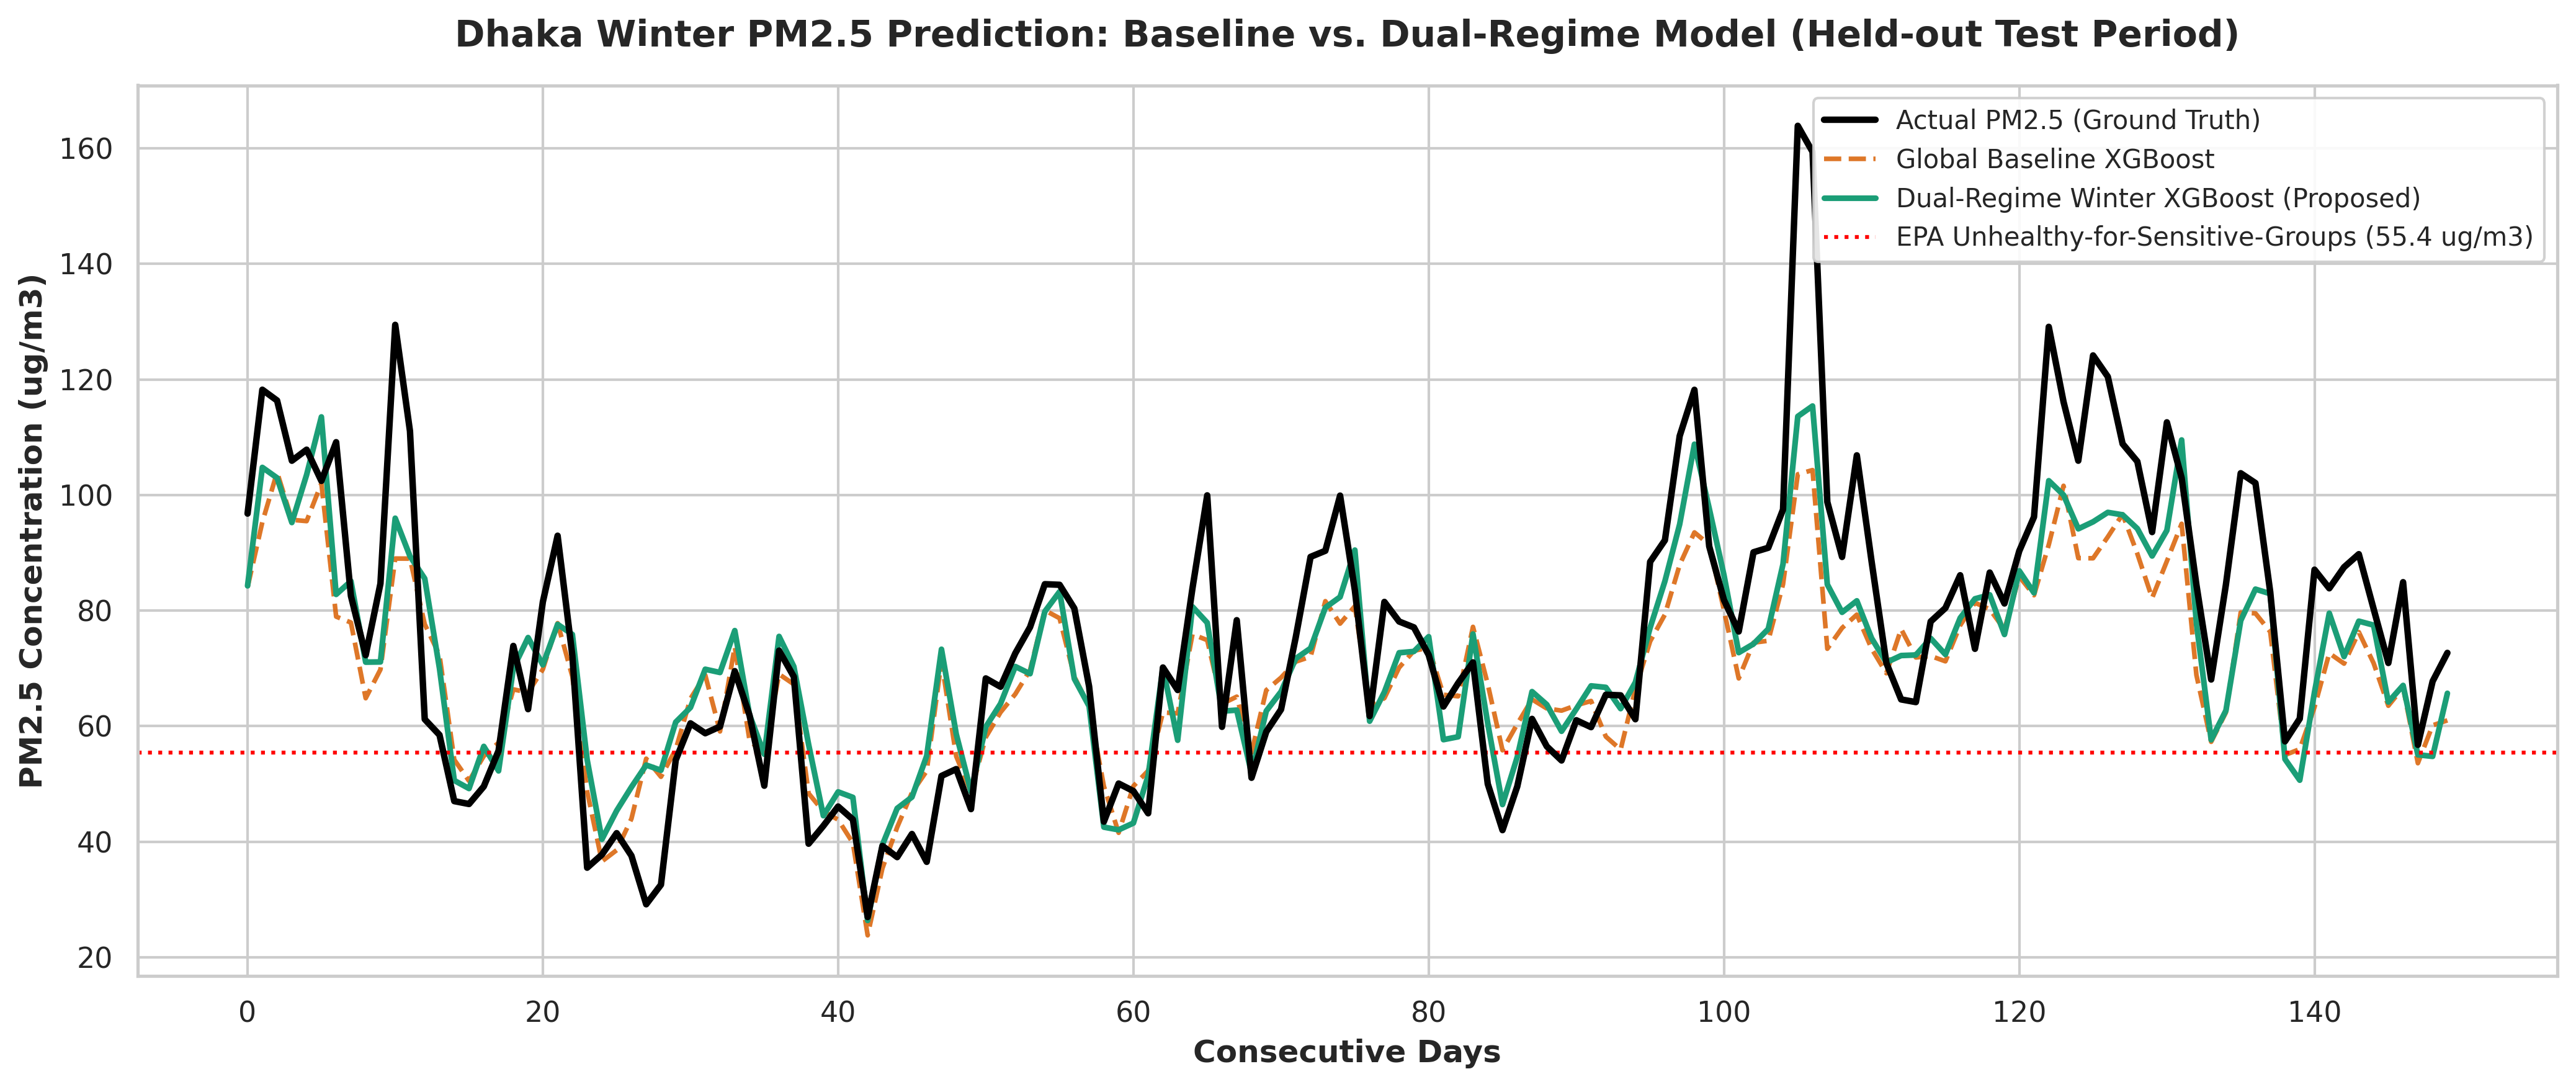

Graph generated using 150 days.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6), dpi=300)

sample_size = min(150, len(y_test_w))
actual_vals = y_test_w.iloc[:sample_size].values
baseline_preds = baseline_model.predict(X_test_w)[:sample_size]
dual_regime_preds = winter_model.predict(X_test_w)[:sample_size]
time_axis = range(sample_size)

plt.plot(time_axis, actual_vals, label='Actual PM2.5 (Ground Truth)', color='black', linewidth=2.5, zorder=3)
plt.plot(time_axis, baseline_preds, label='Global Baseline XGBoost', color='#d95f02', linestyle='--', linewidth=1.8, alpha=0.85)
plt.plot(time_axis, dual_regime_preds, label='Dual-Regime Winter XGBoost (Proposed)', color='#1b9e77', linestyle='-', linewidth=2.2)
plt.axhline(y=55.4, color='red', linestyle=':', linewidth=1.5, label='EPA Unhealthy-for-Sensitive-Groups (55.4 ug/m3)')

plt.title('Dhaka Winter PM2.5 Prediction: Baseline vs. Dual-Regime Model (Held-out Test Period)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Consecutive Days', fontsize=12, fontweight='bold')  # FIXED: was mislabeled "Hours"
plt.ylabel('PM2.5 Concentration (ug/m3)', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig('winter_prediction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Graph generated using {sample_size} days.")


Comprehensive Metrics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score

# --- 1. DISPLAY COMPREHENSIVE METRICS TABLE ---
def get_aqi_code(pm):
    if pm <= 12.0: return 0
    elif pm <= 35.4: return 1
    elif pm <= 55.4: return 2
    elif pm <= 150.4: return 3
    else: return 4

def calc_smape(y_t, y_p):
    return 100 * np.mean(2 * np.abs(y_p - y_t) / (np.abs(y_t) + np.abs(y_p) + 1e-8))

def get_metrics(y_true, y_pred, name):
    return pd.DataFrame({
        "Model Framework": [name],
        "RMSE (µg/m³)": [round(np.sqrt(mean_squared_error(y_true, y_pred)), 2)],
        "MAE (µg/m³)": [round(mean_absolute_error(y_true, y_pred), 2)],
        "R² Score": [round(r2_score(y_true, y_pred), 2)],
        "SMAPE (%)": [round(calc_smape(y_true, y_pred), 2)],
        "Macro F1": [round(f1_score([get_aqi_code(v) for v in y_true], [get_aqi_code(v) for v in y_pred], average='macro', zero_division=0), 2)]
    })

# Align indices cleanly
df_test_eval = df_clean.loc[X_test_combined.index].copy()
df_test_eval['y_true'] = y_test_combined.values
df_test_eval['y_pred_global'] = y_pred_global
df_test_eval['y_pred_multi'] = y_pred_multi

# Explicitly PRINT the results table
df_results = pd.concat([
    get_metrics(df_test_eval['y_true'], df_test_eval['y_pred_global'], "Global Baseline XGBoost"),
    get_metrics(df_test_eval['y_true'], df_test_eval['y_pred_multi'], "Multi-Regime XGBoost (Proposed)")
], ignore_index=True)

print("=== FINAL METRIC RESULTS ===")
display(df_results)

# --- 2. FIXED MONTHLY RMSE CHART ---
monthly_list = []
for m in sorted(df_test_eval['month'].unique()):
    m_data = df_test_eval[df_test_eval['month'] == m]
    if len(m_data) > 3: # Ensure minimum sample size
        r_g = np.sqrt(mean_squared_error(m_data['y_true'], m_data['y_pred_global']))
        r_m = np.sqrt(mean_squared_error(m_data['y_true'], m_data['y_pred_multi']))
        monthly_list.append({'Month': m, 'Global Baseline': r_g, 'Multi-Regime (Proposed)': r_m})

df_m_plot = pd.DataFrame(monthly_list).melt(id_vars='Month', var_name='Framework', value_name='RMSE')

=== FINAL METRIC RESULTS ===


,Model Framework,RMSE (µg/m³),MAE (µg/m³),R² Score,SMAPE (%),Macro F1
0,Global Baseline XGBoost,10.89,7.56,0.88,15.99,0.59
1,Multi-Regime XGBoost (Proposed),9.95,7.18,0.90,16.25,0.57


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Matched regularization across all 4 RF models, same spirit as your XGBoost fit_regularized()
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=42,
    n_jobs=-1,
)

def fit_rf(X_tr, y_tr):
    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_tr, y_tr)
    return model

print("Training Random Forest models...")
rf_global = fit_rf(X_train_g, y_train_g)
rf_winter = fit_rf(X_train_w, y_train_w)
rf_monsoon = fit_rf(X_train_m, y_train_m)
rf_transition = fit_rf(X_train_t, y_train_t)
print("Done.")

# Predict — same paired/matched approach as the XGBoost section
y_pred_rf_w = rf_winter.predict(X_test_w)
y_pred_rf_m = rf_monsoon.predict(X_test_m)
y_pred_rf_t = rf_transition.predict(X_test_t)
y_pred_rf_multi = np.concatenate([y_pred_rf_w, y_pred_rf_m, y_pred_rf_t])

y_pred_rf_global_matched = np.concatenate([
    rf_global.predict(X_test_w), rf_global.predict(X_test_m), rf_global.predict(X_test_t)
])

# y_true_multi already exists from your XGBoost section (same w -> m -> t order)
rmse_rf_g = rmse(y_true_multi, y_pred_rf_global_matched)
r2_rf_g = r2_score(y_true_multi, y_pred_rf_global_matched)
rmse_rf_multi = rmse(y_true_multi, y_pred_rf_multi)
r2_rf_multi = r2_score(y_true_multi, y_pred_rf_multi)

print("\n--- RANDOM FOREST: FULL-YEAR COMPARISON (leak-free) ---")
print(f"RF Global Baseline RMSE : {rmse_rf_g:.2f} (R2: {r2_rf_g:.2f})")
print(f"RF Multi-Regime RMSE    : {rmse_rf_multi:.2f} (R2: {r2_rf_multi:.2f})")
print(f"-> Overall Error Reduction: {((rmse_rf_g - rmse_rf_multi) / rmse_rf_g) * 100:.1f}%")

# Comprehensive metrics table, using your existing get_metrics() helper
df_results_rf = pd.concat([
    get_metrics(y_true_multi, y_pred_rf_global_matched, "Global Baseline Random Forest"),
    get_metrics(y_true_multi, y_pred_rf_multi, "Multi-Regime Random Forest (Proposed)")
], ignore_index=True)

print("\n=== RANDOM FOREST FINAL METRIC RESULTS ===")
display(df_results_rf)

Training Random Forest models...
Done.

--- RANDOM FOREST: FULL-YEAR COMPARISON (leak-free) ---
RF Global Baseline RMSE : 8.89 (R2: 0.92)
RF Multi-Regime RMSE    : 9.41 (R2: 0.91)
-> Overall Error Reduction: -5.9%

=== RANDOM FOREST FINAL METRIC RESULTS ===


,Model Framework,RMSE (µg/m³),MAE (µg/m³),R² Score,SMAPE (%),Macro F1
0,Global Baseline Random Forest,8.89,6.50,0.92,15.0,0.58
1,Multi-Regime Random Forest (Proposed),9.41,6.88,0.91,16.2,0.56


Combined results cel

In [ ]:
from sklearn.metrics import confusion_matrix

# --- Reconstruct a combined test dataframe in the SAME row order as y_true_multi ---
df_test_w_labeled = df_test_all[df_test_all['regime'] == 'Winter_Dry'].copy()
df_test_m_labeled = df_test_all[df_test_all['regime'] == 'Monsoon_Wet'].copy()
df_test_t_labeled = df_test_all[df_test_all['regime'] == 'Transition'].copy()

df_test_combined = pd.concat(
    [df_test_w_labeled, df_test_m_labeled, df_test_t_labeled]
).reset_index(drop=True)

df_test_combined['y_true'] = y_true_multi.values
df_test_combined['y_pred_global_xgb'] = y_pred_global_matched
df_test_combined['y_pred_multi_xgb'] = y_pred_multi
df_test_combined['y_pred_global_rf'] = y_pred_rf_global_matched
df_test_combined['y_pred_multi_rf'] = y_pred_rf_multi

# --- Per-regime baseline vs specialist reduction, for BOTH frameworks (Figure 1) ---
def compute_regime_reduction(baseline_model, specialists, framework_name):
    rows = []
    test_sets = {
        'Winter_Dry': (X_test_w, y_test_w),
        'Monsoon_Wet': (X_test_m, y_test_m),
        'Transition': (X_test_t, y_test_t),
    }
    for regime, (Xte, yte) in test_sets.items():
        yp_base = baseline_model.predict(Xte)
        yp_spec = specialists[regime].predict(Xte)
        rb, rs = rmse(yte, yp_base), rmse(yte, yp_spec)
        rows.append({
            'Framework': framework_name, 'Regime': regime,
            'RMSE_Baseline': rb, 'RMSE_Specialist': rs,
            'Reduction_%': (rb - rs) / rb * 100
        })
    return pd.DataFrame(rows)

df_reduction_xgb = compute_regime_reduction(
    baseline_model,
    {'Winter_Dry': winter_model, 'Monsoon_Wet': monsoon_model, 'Transition': transition_model},
    'XGBoost'
)
df_reduction_rf = compute_regime_reduction(
    rf_global,
    {'Winter_Dry': rf_winter, 'Monsoon_Wet': rf_monsoon, 'Transition': rf_transition},
    'Random Forest'
)
df_reduction_all = pd.concat([df_reduction_xgb, df_reduction_rf], ignore_index=True)
display(df_reduction_all)

,Framework,Regime,RMSE_Baseline,RMSE_Specialist,Reduction_%
0,XGBoost,Winter_Dry,14.777303,12.830940,13.171299
1,XGBoost,Monsoon_Wet,4.752214,5.385246,-13.320763
2,XGBoost,Transition,9.014609,9.119175,-1.159958
3,Random Forest,Winter_Dry,11.288947,11.583625,-2.610323
4,Random Forest,Monsoon_Wet,4.804907,5.360191,-11.556618
5,Random Forest,Transition,8.547593,9.627999,-12.639884


Figure 1 — Per-regime error reduction, both frameworks

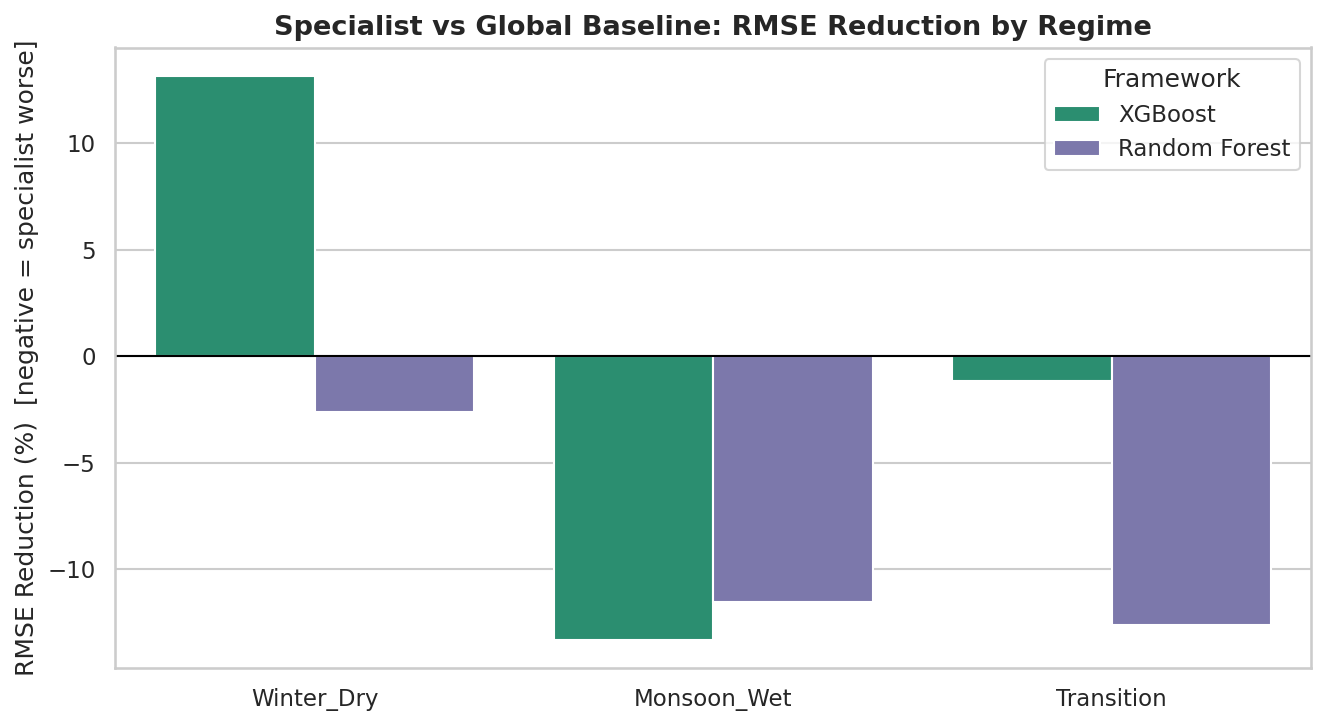

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
sns.barplot(data=df_reduction_all, x='Regime', y='Reduction_%', hue='Framework', ax=ax,
            palette={'XGBoost': '#1b9e77', 'Random Forest': '#7570b3'})
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Specialist vs Global Baseline: RMSE Reduction by Regime', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE Reduction (%)  [negative = specialist worse]')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('fig1_regime_reduction.png', dpi=300, bbox_inches='tight')
plt.show()

. Figure 2 — Predicted vs actual scatter, colored by regime

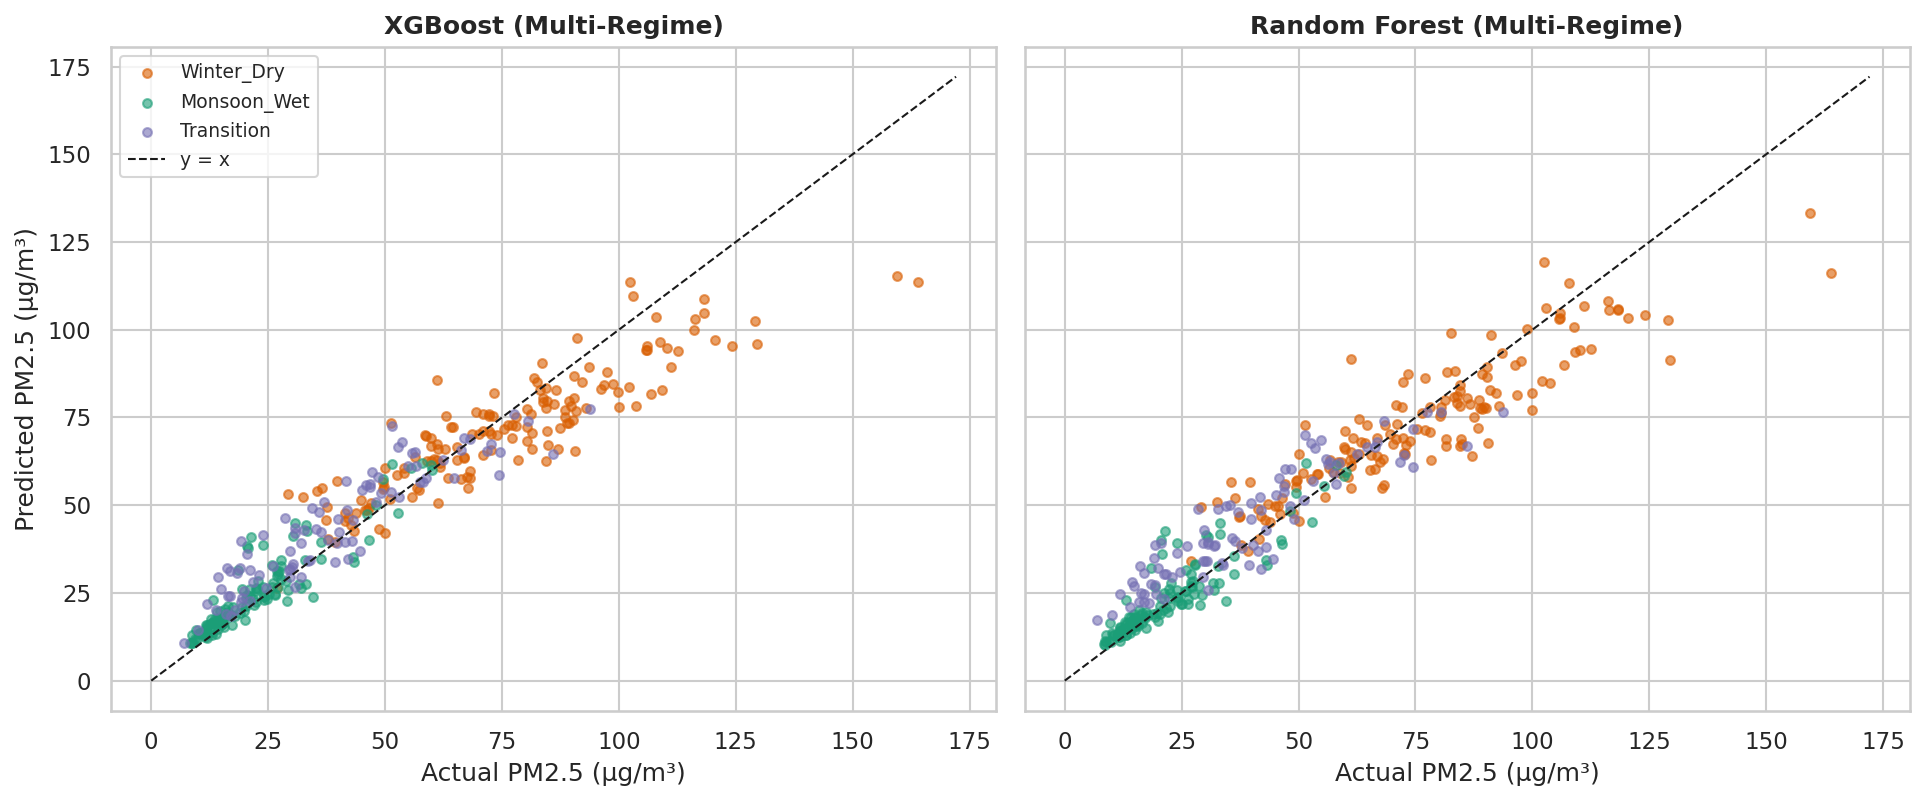

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=150, sharex=True, sharey=True)
regime_colors = {'Winter_Dry': '#d95f02', 'Monsoon_Wet': '#1b9e77', 'Transition': '#7570b3'}

for ax, pred_col, title in zip(
    axes,
    ['y_pred_multi_xgb', 'y_pred_multi_rf'],
    ['XGBoost (Multi-Regime)', 'Random Forest (Multi-Regime)']
):
    for regime, color in regime_colors.items():
        sub = df_test_combined[df_test_combined['regime'] == regime]
        ax.scatter(sub['y_true'], sub[pred_col], s=18, alpha=0.6, color=color, label=regime)
    lims = [0, df_test_combined['y_true'].max() * 1.05]
    ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig2_pred_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 3 — PM2.5 distribution by regime (data-only, can be placed earlier)

/tmp/ipykernel_748/3015648034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='regime', y=pm25_col, order=order, ax=ax,


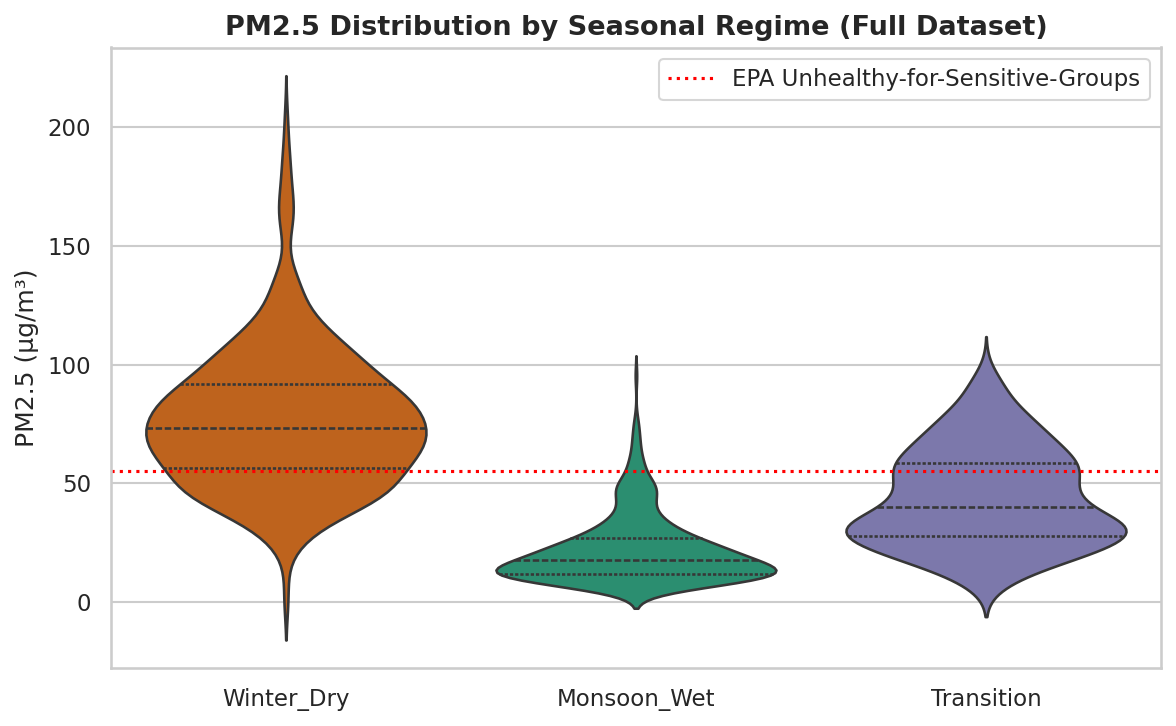

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
order = ['Winter_Dry', 'Monsoon_Wet', 'Transition']
sns.violinplot(data=df_clean, x='regime', y=pm25_col, order=order, ax=ax,
                palette={'Winter_Dry': '#d95f02', 'Monsoon_Wet': '#1b9e77', 'Transition': '#7570b3'},
                inner='quartile')
ax.axhline(THRESH, color='red', linestyle=':', linewidth=1.5, label='EPA Unhealthy-for-Sensitive-Groups')
ax.set_title('PM2.5 Distribution by Seasonal Regime (Full Dataset)', fontsize=13, fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_pm25_by_regime.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 4 — Feature importance per regime model

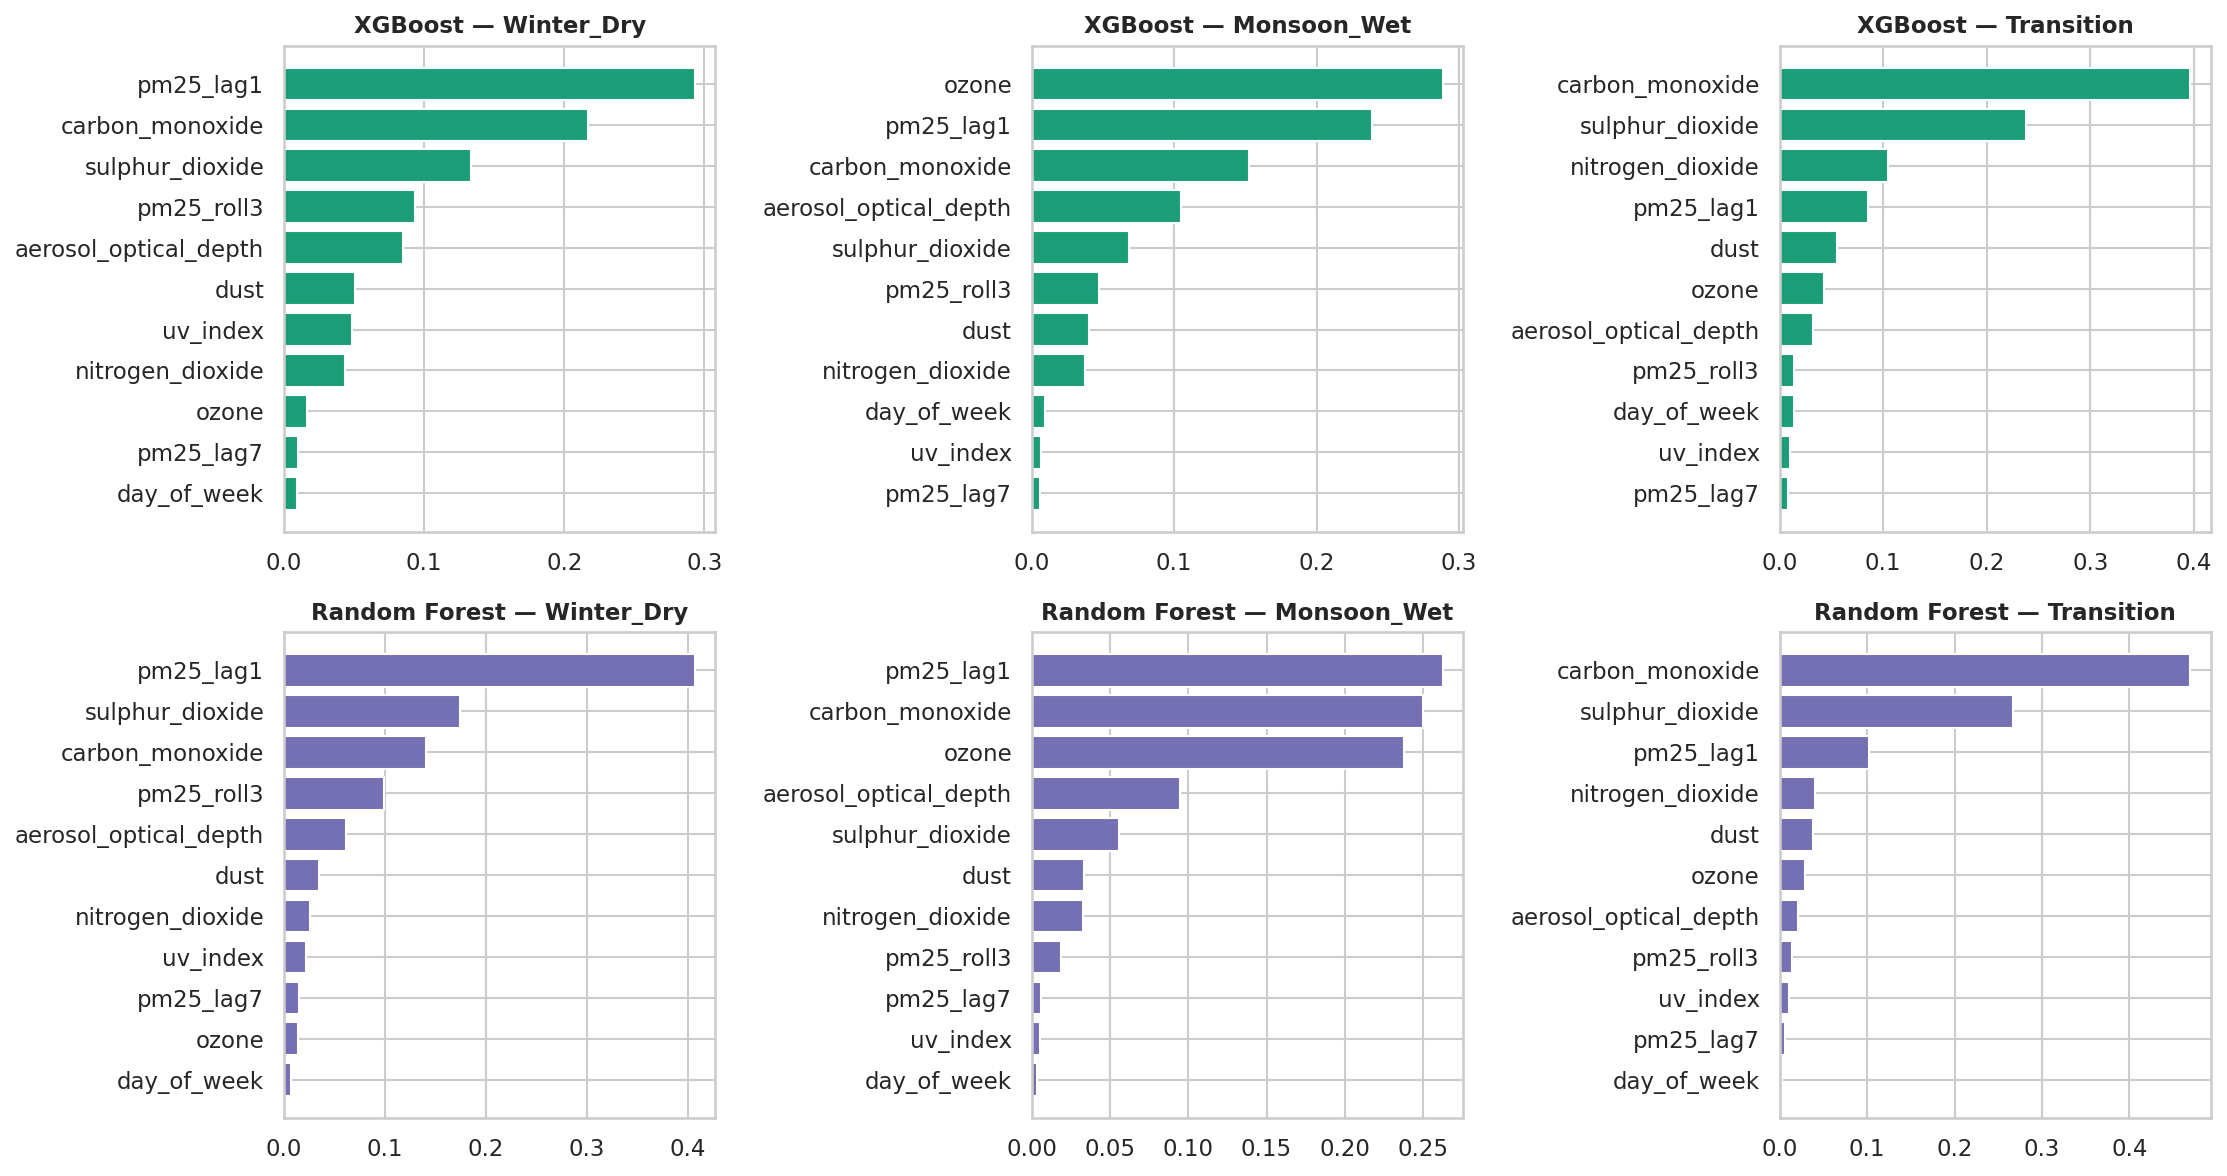

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150, sharex=False)

xgb_models = {'Winter_Dry': winter_model, 'Monsoon_Wet': monsoon_model, 'Transition': transition_model}
rf_models = {'Winter_Dry': rf_winter, 'Monsoon_Wet': rf_monsoon, 'Transition': rf_transition}

for col, regime in enumerate(['Winter_Dry', 'Monsoon_Wet', 'Transition']):
    # XGBoost row
    imp_xgb = pd.Series(xgb_models[regime].feature_importances_, index=features).sort_values()
    axes[0, col].barh(imp_xgb.index, imp_xgb.values, color='#1b9e77')
    axes[0, col].set_title(f'XGBoost — {regime}', fontsize=11, fontweight='bold')

    # Random Forest row
    imp_rf = pd.Series(rf_models[regime].feature_importances_, index=features).sort_values()
    axes[1, col].barh(imp_rf.index, imp_rf.values, color='#7570b3')
    axes[1, col].set_title(f'Random Forest — {regime}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 5 — Monthly RMSE, global vs multi-regime (both frameworks)

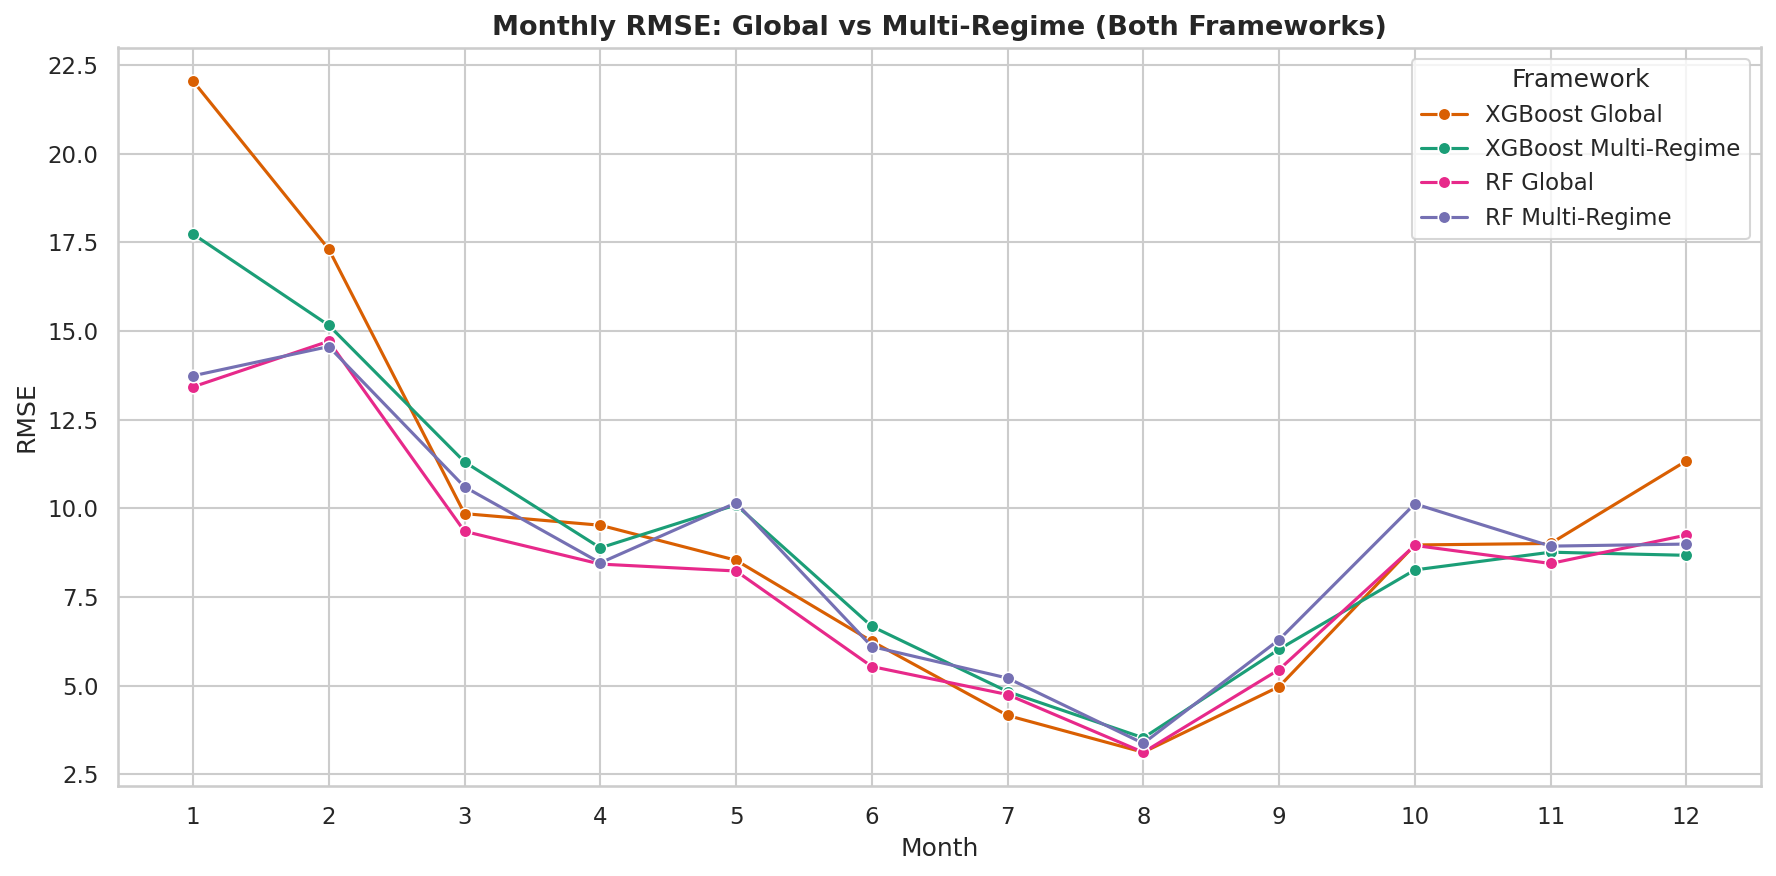

In [ ]:
monthly_rows = []
for m in sorted(df_test_combined['month'].unique()):
    sub = df_test_combined[df_test_combined['month'] == m]
    if len(sub) <= 3:
        continue
    monthly_rows.append({'Month': m, 'Framework': 'XGBoost Global',
                          'RMSE': rmse(sub['y_true'], sub['y_pred_global_xgb'])})
    monthly_rows.append({'Month': m, 'Framework': 'XGBoost Multi-Regime',
                          'RMSE': rmse(sub['y_true'], sub['y_pred_multi_xgb'])})
    monthly_rows.append({'Month': m, 'Framework': 'RF Global',
                          'RMSE': rmse(sub['y_true'], sub['y_pred_global_rf'])})
    monthly_rows.append({'Month': m, 'Framework': 'RF Multi-Regime',
                          'RMSE': rmse(sub['y_true'], sub['y_pred_multi_rf'])})

df_monthly = pd.DataFrame(monthly_rows)

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
sns.lineplot(data=df_monthly, x='Month', y='RMSE', hue='Framework', marker='o', ax=ax,
             palette={'XGBoost Global': '#d95f02', 'XGBoost Multi-Regime': '#1b9e77',
                      'RF Global': '#e7298a', 'RF Multi-Regime': '#7570b3'})
ax.set_title('Monthly RMSE: Global vs Multi-Regime (Both Frameworks)', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig('fig5_monthly_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 6 — AQI-category confusion matrix, baseline vs multi-regime

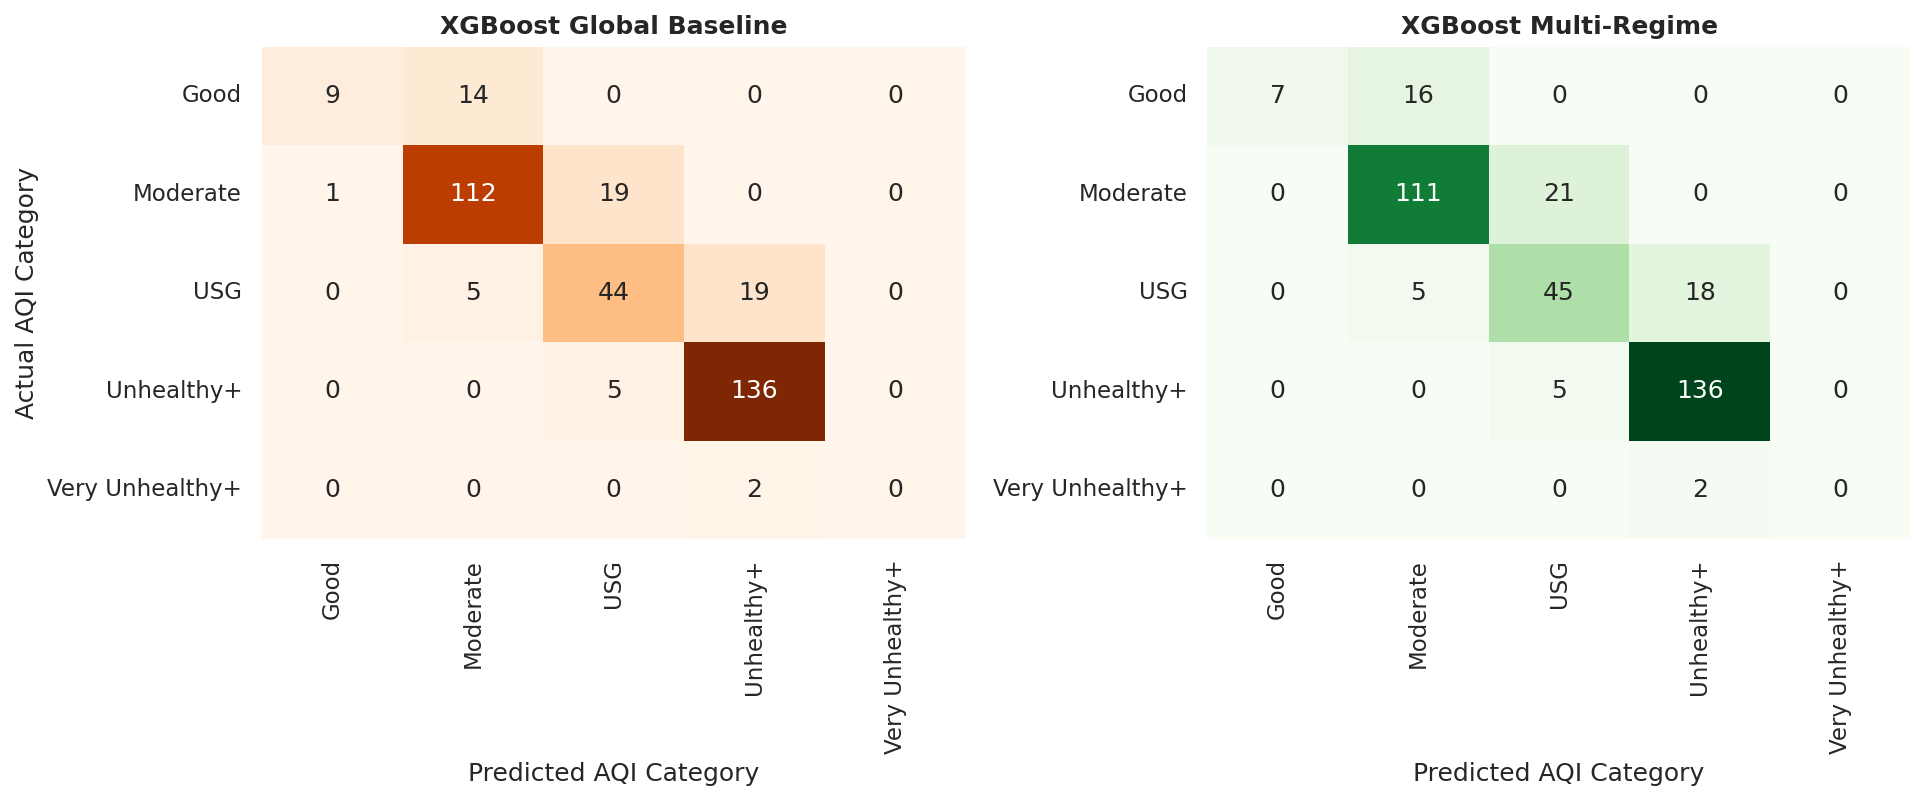

In [ ]:
aqi_labels = ['Good', 'Moderate', 'USG', 'Unhealthy+', 'Very Unhealthy+']

y_true_aqi = df_test_combined['y_true'].apply(get_aqi_code)
y_pred_global_aqi = df_test_combined['y_pred_global_xgb'].apply(get_aqi_code)
y_pred_multi_aqi = df_test_combined['y_pred_multi_xgb'].apply(get_aqi_code)

present_codes = sorted(set(y_true_aqi) | set(y_pred_global_aqi) | set(y_pred_multi_aqi))
labels_present = [aqi_labels[i] for i in present_codes]

cm_global = confusion_matrix(y_true_aqi, y_pred_global_aqi, labels=present_codes)
cm_multi = confusion_matrix(y_true_aqi, y_pred_multi_aqi, labels=present_codes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=150)
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_present, yticklabels=labels_present, ax=axes[0], cbar=False)
axes[0].set_title('XGBoost Global Baseline', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted AQI Category')
axes[0].set_ylabel('Actual AQI Category')

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_present, yticklabels=labels_present, ax=axes[1], cbar=False)
axes[1].set_title('XGBoost Multi-Regime', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted AQI Category')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig6_aqi_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

LightGBM

In [ ]:
!pip install lightgbm -q

LightGBM implementation

In [ ]:
X_train_g
y_train_g
X_test_g
y_test_g

X_train_w
y_train_w
X_test_w
y_test_w

X_train_m
y_train_m
X_test_m
y_test_m

X_train_t
y_train_t
X_test_t
y_test_t

,pm2_5
42,44.558333
43,43.008333
44,43.045833
45,46.837500
46,47.200000
...,...
251,80.541667
252,74.558333
253,39.787500
254,35.320833


Import and parameters

In [ ]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    f1_score
)
import numpy as np
import pandas as pd


# ============================================================
# LIGHTGBM PARAMETERS
# ============================================================

LGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    verbosity=-1
)

Chronological validation function

In [ ]:
# ============================================================
# CHRONOLOGICAL LIGHTGBM TRAINING
# ============================================================

def fit_lgbm(X_tr, y_tr, val_frac=0.15):

    n_val = max(int(len(X_tr) * val_frac), 10)

    # Chronological split:
    # earlier observations -> training
    # latest observations  -> validation
    X_fit = X_tr.iloc[:-n_val]
    X_val = X_tr.iloc[-n_val:]

    y_fit = y_tr.iloc[:-n_val]
    y_val = y_tr.iloc[-n_val:]

    model = LGBMRegressor(**LGB_PARAMS)

    model.fit(
        X_fit,
        y_fit,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[
            early_stopping(30, verbose=False),
            log_evaluation(0)
        ]
    )

    print(
        f"Best iteration: "
        f"{model.best_iteration_} "
        f"(out of {LGB_PARAMS['n_estimators']} max)"
    )

    return model

Train all four LightGBM models

In [ ]:
# ============================================================
# TRAIN LIGHTGBM MODELS
# ============================================================

print("Training LightGBM models...\n")

print("Global:")
lgb_global = fit_lgbm(X_train_g, y_train_g)

print("\nWinter:")
lgb_winter = fit_lgbm(X_train_w, y_train_w)

print("\nMonsoon:")
lgb_monsoon = fit_lgbm(X_train_m, y_train_m)

print("\nTransition:")
lgb_transition = fit_lgbm(X_train_t, y_train_t)

print("\nAll LightGBM models trained.")

Training LightGBM models...

Global:
Best iteration: 252 (out of 1000 max)

Winter:
Best iteration: 239 (out of 1000 max)

Monsoon:
Best iteration: 129 (out of 1000 max)

Transition:
Best iteration: 248 (out of 1000 max)

All LightGBM models trained.


Check overfitting

In [ ]:
# ============================================================
# LIGHTGBM OVERFIT CHECK
# ============================================================

print("\n--- LIGHTGBM OVERFIT CHECK ---")

for name, model, Xtr, ytr, Xte, yte in [
    ("Global", lgb_global, X_train_g, y_train_g, X_test_g, y_test_g),
    ("Winter", lgb_winter, X_train_w, y_train_w, X_test_w, y_test_w),
    ("Monsoon", lgb_monsoon, X_train_m, y_train_m, X_test_m, y_test_m),
    ("Transition", lgb_transition, X_train_t, y_train_t, X_test_t, y_test_t),
]:

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    train_rmse = np.sqrt(mean_squared_error(ytr, train_pred))
    test_rmse = np.sqrt(mean_squared_error(yte, test_pred))

    gap = test_rmse - train_rmse

    print(
        f"{name:12s} | "
        f"Train RMSE: {train_rmse:6.2f} | "
        f"Test RMSE: {test_rmse:6.2f} | "
        f"Gap: {gap:6.2f}"
    )


--- LIGHTGBM OVERFIT CHECK ---
Global       | Train RMSE:   8.01 | Test RMSE:  10.82 | Gap:   2.81
Winter       | Train RMSE:   9.06 | Test RMSE:  13.12 | Gap:   4.06
Monsoon      | Train RMSE:   2.85 | Test RMSE:   5.49 | Gap:   2.63
Transition   | Train RMSE:   3.53 | Test RMSE:   9.19 | Gap:   5.67


Per-regime comparison

In [ ]:
# ============================================================
# LIGHTGBM PER-REGIME COMPARISON
# ============================================================

print("\n--- LIGHTGBM: PER-REGIME GLOBAL VS SPECIALIST ---")

lgb_regime_results = []

for regime, Xte, yte, specialist in [
    ("Winter_Dry", X_test_w, y_test_w, lgb_winter),
    ("Monsoon_Wet", X_test_m, y_test_m, lgb_monsoon),
    ("Transition", X_test_t, y_test_t, lgb_transition),
]:

    # Global model prediction on this regime
    pred_global = lgb_global.predict(Xte)

    # Specialist model prediction
    pred_specialist = specialist.predict(Xte)

    rmse_global = np.sqrt(
        mean_squared_error(yte, pred_global)
    )

    rmse_specialist = np.sqrt(
        mean_squared_error(yte, pred_specialist)
    )

    r2_global = r2_score(yte, pred_global)
    r2_specialist = r2_score(yte, pred_specialist)

    reduction = (
        (rmse_global - rmse_specialist)
        / rmse_global
        * 100
    )

    lgb_regime_results.append({
        "Regime": regime,
        "Global_RMSE": rmse_global,
        "Specialist_RMSE": rmse_specialist,
        "Global_R2": r2_global,
        "Specialist_R2": r2_specialist,
        "RMSE_Reduction_%": reduction
    })

    print(
        f"\n[{regime}]"
        f"\nGlobal     RMSE: {rmse_global:.2f} | R²: {r2_global:.2f}"
        f"\nSpecialist RMSE: {rmse_specialist:.2f} | R²: {r2_specialist:.2f}"
        f"\nRMSE change: {reduction:+.2f}%"
    )

df_lgb_regime = pd.DataFrame(lgb_regime_results)

print("\n--- LIGHTGBM REGIME RESULTS ---")
display(df_lgb_regime)


--- LIGHTGBM: PER-REGIME GLOBAL VS SPECIALIST ---

[Winter_Dry]
Global     RMSE: 14.68 | R²: 0.65
Specialist RMSE: 13.12 | R²: 0.72
RMSE change: +10.65%

[Monsoon_Wet]
Global     RMSE: 4.67 | R²: 0.85
Specialist RMSE: 5.49 | R²: 0.79
RMSE change: -17.50%

[Transition]
Global     RMSE: 8.98 | R²: 0.78
Specialist RMSE: 9.19 | R²: 0.77
RMSE change: -2.40%

--- LIGHTGBM REGIME RESULTS ---


,Regime,Global_RMSE,Specialist_RMSE,Global_R2,Specialist_R2,RMSE_Reduction_%
0,Winter_Dry,14.683552,13.119879,0.651670,0.721908,10.649144
1,Monsoon_Wet,4.670242,5.487734,0.845195,0.786257,-17.504270
2,Transition,8.976792,9.191875,0.781651,0.771062,-2.395980


Full-year Global vs Multi-Regime comparison

In [ ]:
# ============================================================
# LIGHTGBM FULL-YEAR COMPARISON
# ============================================================

# Specialist predictions
y_pred_lgb_w = lgb_winter.predict(X_test_w)
y_pred_lgb_m = lgb_monsoon.predict(X_test_m)
y_pred_lgb_t = lgb_transition.predict(X_test_t)

# Combine in the same W -> M -> T order
y_pred_lgb_multi = np.concatenate([
    y_pred_lgb_w,
    y_pred_lgb_m,
    y_pred_lgb_t
])

# Global model predictions on exactly the same rows
y_pred_lgb_global_matched = np.concatenate([
    lgb_global.predict(X_test_w),
    lgb_global.predict(X_test_m),
    lgb_global.predict(X_test_t)
])

# Ground truth
y_true_lgb = y_true_multi.copy()

# Metrics
rmse_lgb_global = np.sqrt(
    mean_squared_error(
        y_true_lgb,
        y_pred_lgb_global_matched
    )
)

rmse_lgb_multi = np.sqrt(
    mean_squared_error(
        y_true_lgb,
        y_pred_lgb_multi
    )
)

r2_lgb_global = r2_score(
    y_true_lgb,
    y_pred_lgb_global_matched
)

r2_lgb_multi = r2_score(
    y_true_lgb,
    y_pred_lgb_multi
)

print("\n--- LIGHTGBM: FULL-YEAR COMPARISON ---")

print(
    f"Global LightGBM      RMSE: {rmse_lgb_global:.2f} "
    f"| R²: {r2_lgb_global:.2f}"
)

print(
    f"Multi-Regime LightGBM RMSE: {rmse_lgb_multi:.2f} "
    f"| R²: {r2_lgb_multi:.2f}"
)

print(
    f"Overall RMSE change: "
    f"{((rmse_lgb_global - rmse_lgb_multi) / rmse_lgb_global) * 100:.2f}%"
)


--- LIGHTGBM: FULL-YEAR COMPARISON ---
Global LightGBM      RMSE: 10.82 | R²: 0.88
Multi-Regime LightGBM RMSE: 10.14 | R²: 0.89
Overall RMSE change: 6.31%
